In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, mean_absolute_error
import xgboost as xgb

In [2]:
import pandas as pd

df = pd.read_excel('456.xlsx') 

pivot_df = df.pivot_table(
    index=['Турнир', 'Игрок', 'Амплуа', 'Команда', 'Матч', 'ИндексНаМатч_90', 'ИгровоеВремя'],
    columns='Данные',
    values='КоличествоДействий',
    aggfunc='sum',
    fill_value=0
)

pivot_df = pivot_df.reset_index()

pivot_df.head()

Данные,Турнир,Игрок,Амплуа,Команда,Матч,ИндексНаМатч_90,ИгровоеВремя,Автогол,Блокировка навеса,Блокировка передачи,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга","Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга"
0,Молодежное первенство,Абдинов Фарид (2008),CD,Рубин-М,Нижний Новгород-М 0 : 2 Рубин-М (27.06.2025),73.16316,46.6218,0,0,0,...,0,1,0,0,0,2,0,0,2,0
1,Молодежное первенство,Абдинов Фарид (2008),CD,Рубин-М,Рубин-М 0 : 1 Сочи-М (04.07.2025),182.32443,50.2017,0,1,1,...,0,0,0,0,0,2,0,0,2,1
2,Молодежное первенство,Абдинов Фарид (2008),CD,Рубин-М,Рубин-М 2 : 2 Краснодар-М (14.03.2025),51.59916,95.0596,0,0,3,...,0,0,3,0,0,3,1,0,2,0
3,Молодежное первенство,Абдулхаликов Арсений (2007),AM,Динамо-М,Динамо-М 1 : 0 Нижний Новгород-М (25.04.2025),93.14172,68.7017,0,0,3,...,2,0,0,2,0,3,5,0,0,1
4,Молодежное первенство,Абдулхаликов Арсений (2007),AM,Динамо-М,Урал-М 0 : 5 Динамо-М (16.05.2025),191.14803,45.2241,0,0,0,...,0,2,1,1,1,6,1,2,1,0


In [3]:
pivot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21294 entries, 0 to 21293
Columns: 115 entries, Турнир to Эффективность "-" Продвижения мяча вперед за счет дриблинга
dtypes: float64(2), int64(108), object(5)
memory usage: 18.7+ MB


In [4]:
nan_counts = pivot_df.isna().sum()

print("Количество NaN:")
print(nan_counts[nan_counts > 0])

Количество NaN:
Series([], dtype: int64)


In [5]:
pivot_df_mp = pivot_df[pivot_df['Турнир'] == 'Молодежное первенство']

pivot_df_1 = pivot_df[pivot_df['Турнир'] == 'ЮФЛ-1']

pivot_df_2 = pivot_df[pivot_df['Турнир'] == 'ЮФЛ-2']

pivot_df_3 = pivot_df[pivot_df['Турнир'] == 'ЮФЛ-3']

In [6]:
pivot_df_mp.describe()

Данные,ИндексНаМатч_90,ИгровоеВремя,Автогол,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,Борьба за нейтральный мяч удачная,В запасе,Выносы мяча,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга","Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга"
count,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,...,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000,5678.000000
mean,59.533826,59.533425,0.001585,0.073265,0.414583,0.169602,1.886051,1.880416,0.000176,0.240754,...,0.162557,0.258894,0.807503,0.769989,0.264354,1.961782,0.558295,0.221205,1.429024,0.496302
std,55.264787,31.349743,0.039785,0.299586,0.733466,0.476629,1.961460,1.958788,0.013271,0.593828,...,0.446733,0.575684,1.077465,1.103393,0.618573,2.179246,1.028586,0.582186,1.604934,0.839342
min,-209.514150,5.016900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.719622,29.372900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.810775,63.589900,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,87.727208,93.754225,0.000000,0.000000,1.000000,0.000000,3.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,3.000000,1.000000,0.000000,2.000000,1.000000
max,380.451240,105.454500,1.000000,5.000000,6.000000,4.000000,15.000000,13.000000,1.000000,5.000000,...,5.000000,5.000000,7.000000,10.000000,7.000000,14.000000,14.000000,5.000000,13.000000,10.000000


In [7]:
pivot_df_1.describe()

Данные,ИндексНаМатч_90,ИгровоеВремя,Автогол,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,Борьба за нейтральный мяч удачная,В запасе,Выносы мяча,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга","Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга"
count,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.0,4930.000000,...,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000,4930.000000
mean,62.540756,58.946138,0.001420,0.068763,0.398580,0.182150,2.160243,2.153144,0.0,0.263286,...,0.167140,0.308519,0.785801,0.756998,0.307505,2.153955,0.564097,0.277079,1.581542,0.555578
std,56.561366,32.013083,0.037658,0.274606,0.712151,0.527289,2.219512,2.167344,0.0,0.657101,...,0.454967,0.654237,1.039473,1.094712,0.693099,2.329612,0.972355,0.710400,1.812119,0.950091
min,-159.665220,5.003400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.317608,27.414950,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.221020,63.521050,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,93.128985,93.210000,0.000000,0.000000,1.000000,0.000000,3.000000,3.000000,0.0,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,3.000000,1.000000,0.000000,2.000000,1.000000
max,389.271690,103.386900,1.000000,3.000000,5.000000,5.000000,17.000000,13.000000,0.0,7.000000,...,4.000000,5.000000,7.000000,9.000000,7.000000,15.000000,8.000000,13.000000,15.000000,8.000000


In [8]:
pivot_df_2.describe()

Данные,ИндексНаМатч_90,ИгровоеВремя,Автогол,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,Борьба за нейтральный мяч удачная,В запасе,Выносы мяча,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга","Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга"
count,5452.000000,5452.000000,5452.000000,5452.000000,5452.000000,5452.00000,5452.000000,5452.00000,5452.0,5452.000000,...,5452.000000,5452.000000,5452.000000,5452.000000,5452.000000,5452.000000,5452.000000,5452.000000,5452.000000,5452.000000
mean,58.643932,59.194731,0.002201,0.070249,0.418195,0.16416,2.231842,2.22157,0.0,0.253668,...,0.153522,0.305209,0.789985,0.759354,0.298973,2.129494,0.536317,0.252568,1.695341,0.533382
std,53.646160,32.013790,0.046868,0.287352,0.729708,0.48270,2.255914,2.25353,0.0,0.596906,...,0.432258,0.644770,1.037415,1.056318,0.659196,2.303538,0.949254,0.601657,1.899075,0.894645
min,-214.458120,5.025300,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.899207,27.759750,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.019045,62.963450,0.000000,0.000000,0.000000,0.00000,2.000000,2.00000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,89.129362,93.531700,0.000000,0.000000,1.000000,0.00000,3.000000,3.00000,0.0,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,3.000000,1.000000,0.000000,3.000000,1.000000
max,384.649650,112.158600,1.000000,3.000000,5.000000,6.00000,21.000000,15.00000,0.0,5.000000,...,4.000000,7.000000,7.000000,8.000000,7.000000,16.000000,9.000000,5.000000,13.000000,8.000000


In [9]:
pivot_df_3.describe()

Данные,ИндексНаМатч_90,ИгровоеВремя,Автогол,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,Борьба за нейтральный мяч удачная,В запасе,Выносы мяча,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга","Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга"
count,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,...,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000
mean,56.087510,54.919458,0.001337,0.081582,0.425487,0.157050,2.281620,2.277799,0.000191,0.263088,...,0.145395,0.282767,0.733665,0.699083,0.272067,2.013756,0.537447,0.265762,1.727360,0.550439
std,55.243172,28.357196,0.036550,0.307920,0.734537,0.469783,2.359481,2.349790,0.013822,0.612740,...,0.424357,0.595785,0.995761,1.016118,0.616137,2.212615,1.039186,0.640282,1.899638,0.912489
min,-162.083880,5.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.274952,27.117675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.290155,61.251800,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,84.950190,83.422200,0.000000,0.000000,1.000000,0.000000,3.000000,4.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,3.000000,1.000000,0.000000,3.000000,1.000000
max,365.386050,90.603500,1.000000,4.000000,6.000000,6.000000,18.000000,23.000000,1.000000,5.000000,...,5.000000,5.000000,8.000000,8.000000,6.000000,14.000000,16.000000,6.000000,12.000000,10.000000


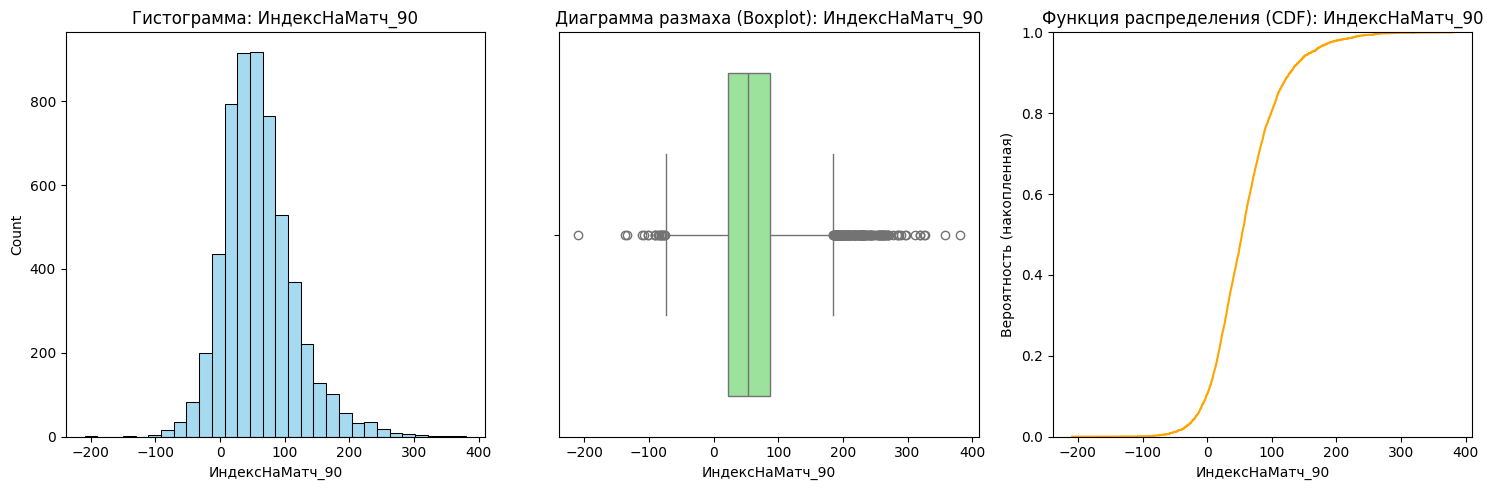

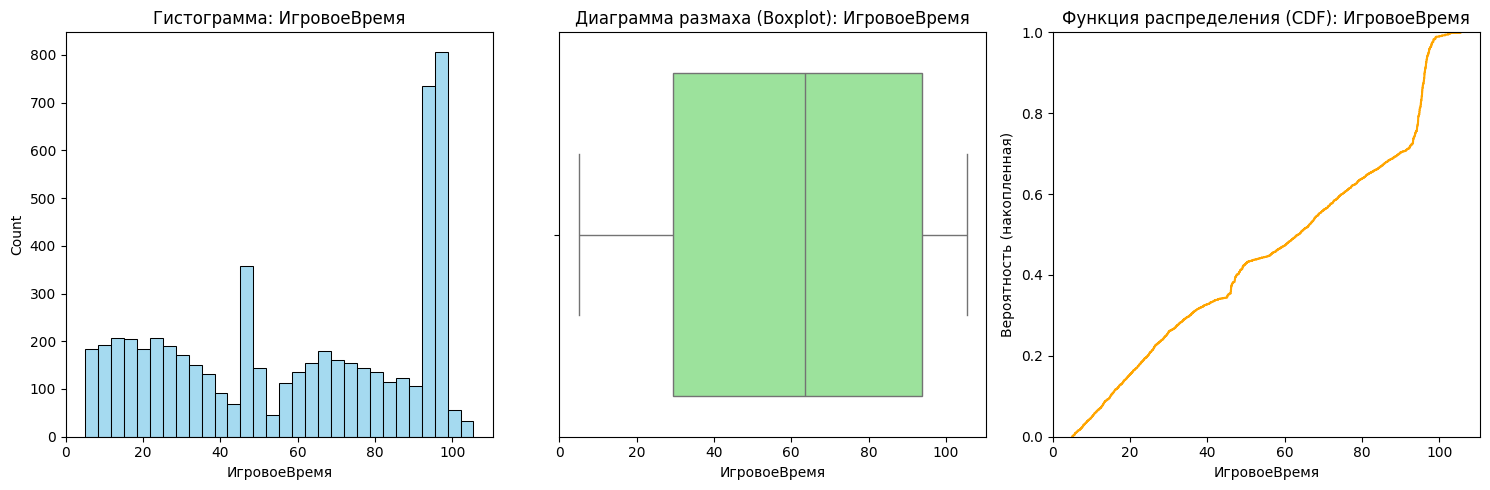

In [10]:
# Список выбранных столбцов
selected_columns = ['ИндексНаМатч_90', 'ИгровоеВремя']

# Гистограммы
for col in selected_columns:
    if col in pivot_df_mp.columns:
        plt.figure(figsize=(15, 5))

        # Гистограмма
        plt.subplot(1, 3, 1)
        sns.histplot(pivot_df_mp[col].dropna(), kde=False, bins=30, color='skyblue')
        plt.title(f'Гистограмма: {col}')
        plt.xlabel(col)

        # Диаграмма размаха (boxplot)
        plt.subplot(1, 3, 2)
        sns.boxplot(x=pivot_df_mp[col], color='lightgreen')
        plt.title(f'Диаграмма размаха (Boxplot): {col}')

        # Функция распределения
        plt.subplot(1, 3, 3)
        try:
            sns.ecdfplot(pivot_df_mp[col].dropna(), color='orange')
            plt.title(f'Функция распределения (CDF): {col}')
            plt.xlabel(col)
            plt.ylabel('Вероятность (накопленная)')
        except Exception as e:
            plt.text(0.5, 0.5, f'Ошибка: {e}', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Столбец '{col}' не найден в DataFrame")

In [11]:
# Считаем дисперсию до удаления
variance_index_mp_before = pivot_df_mp['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_mp_before}")

threshold1 = -80
threshold = 200

data_delete_index_mp = pivot_df_mp[pivot_df_mp['ИндексНаМатч_90'] < threshold]
data_delete_index_mp = data_delete_index_mp[data_delete_index_mp['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_mp_after = data_delete_index_mp['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_mp_after}")

Дисперсия до удаления: 3054.196707263455
Дисперсия после удаления: 2323.6140148302725


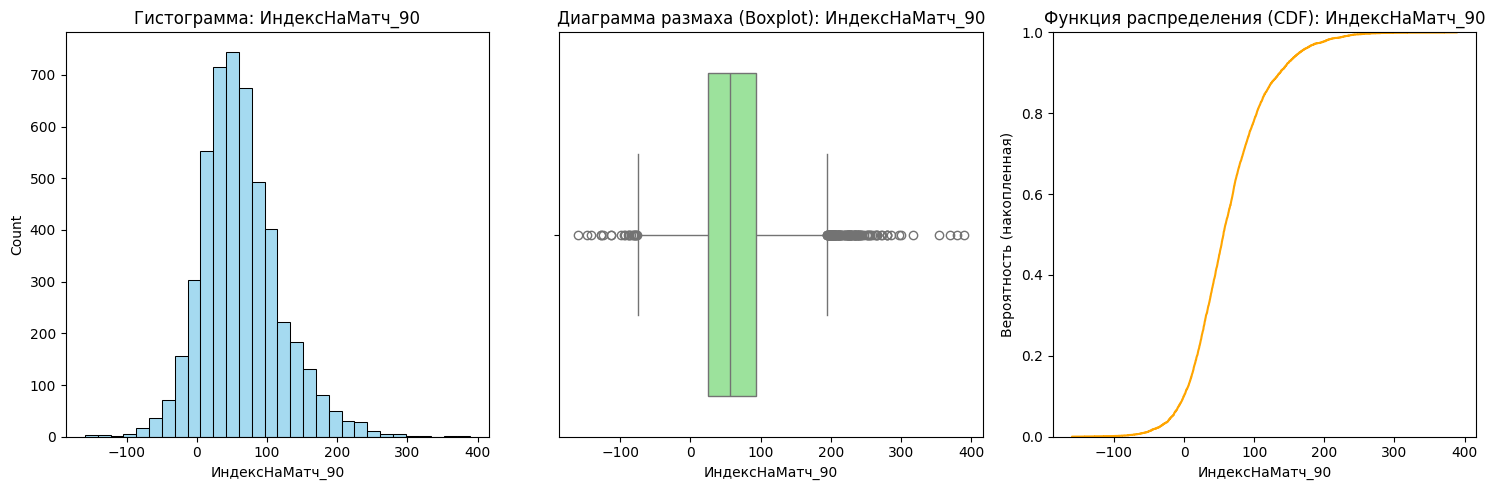

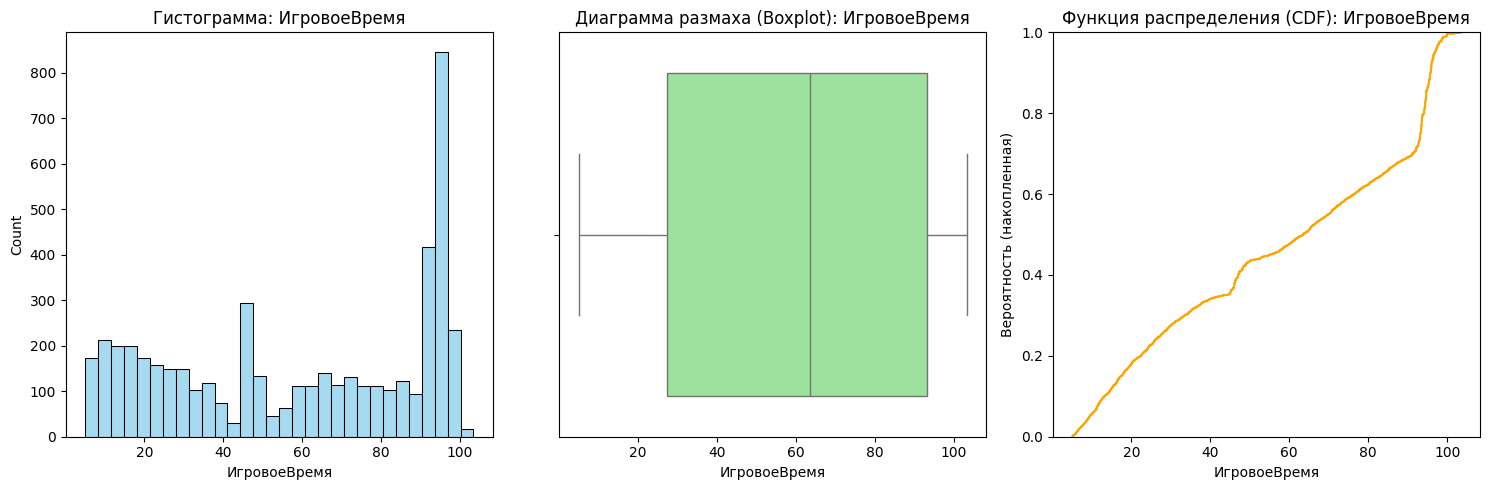

In [12]:
# Список выбранных столбцов
selected_columns = ['ИндексНаМатч_90', 'ИгровоеВремя']

# Гистограммы
for col in selected_columns:
    if col in pivot_df_1.columns:
        plt.figure(figsize=(15, 5))

        # Гистограмма
        plt.subplot(1, 3, 1)
        sns.histplot(pivot_df_1[col].dropna(), kde=False, bins=30, color='skyblue')
        plt.title(f'Гистограмма: {col}')
        plt.xlabel(col)

        # Диаграмма размаха (boxplot)
        plt.subplot(1, 3, 2)
        sns.boxplot(x=pivot_df_1[col], color='lightgreen')
        plt.title(f'Диаграмма размаха (Boxplot): {col}')

        # Функция распределения
        plt.subplot(1, 3, 3)
        try:
            sns.ecdfplot(pivot_df_1[col].dropna(), color='orange')
            plt.title(f'Функция распределения (CDF): {col}')
            plt.xlabel(col)
            plt.ylabel('Вероятность (накопленная)')
        except Exception as e:
            plt.text(0.5, 0.5, f'Ошибка: {e}', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Столбец '{col}' не найден в DataFrame")

In [13]:
# Считаем дисперсию до удаления
variance_index_1_before = pivot_df_1['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_1_before}")

threshold1 = -80
threshold = 200

data_delete_index_1 = pivot_df_1[pivot_df_1['ИндексНаМатч_90'] < threshold]
data_delete_index_1 = data_delete_index_1[data_delete_index_1['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_1_after = data_delete_index_1['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_1_after}")

Дисперсия до удаления: 3199.1881274596735
Дисперсия после удаления: 2463.073189990354


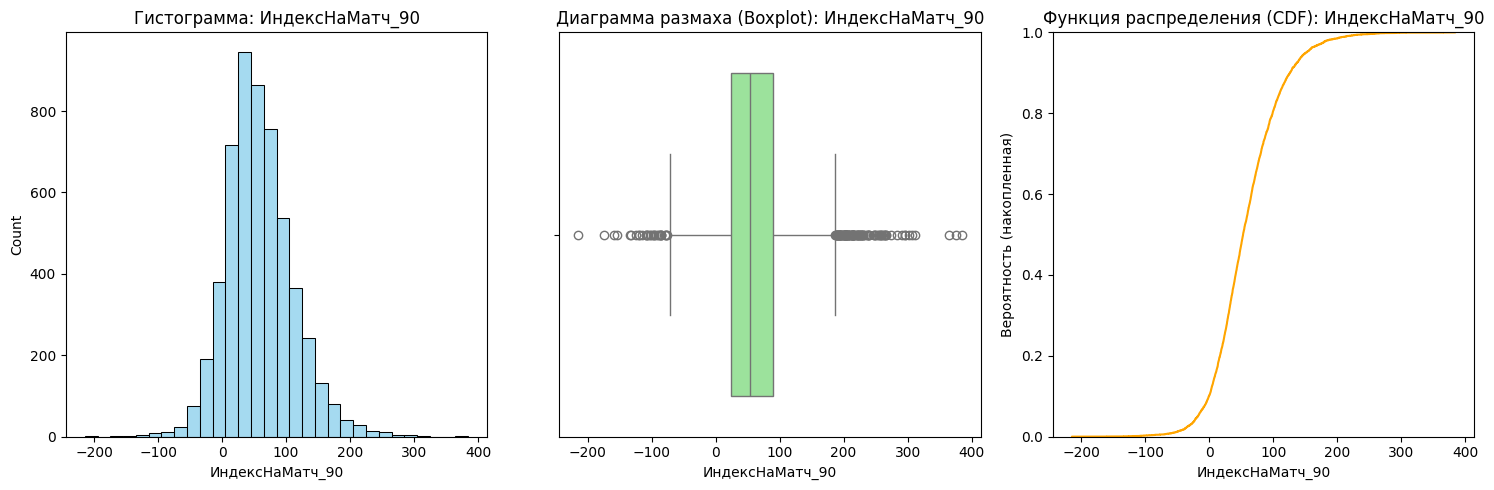

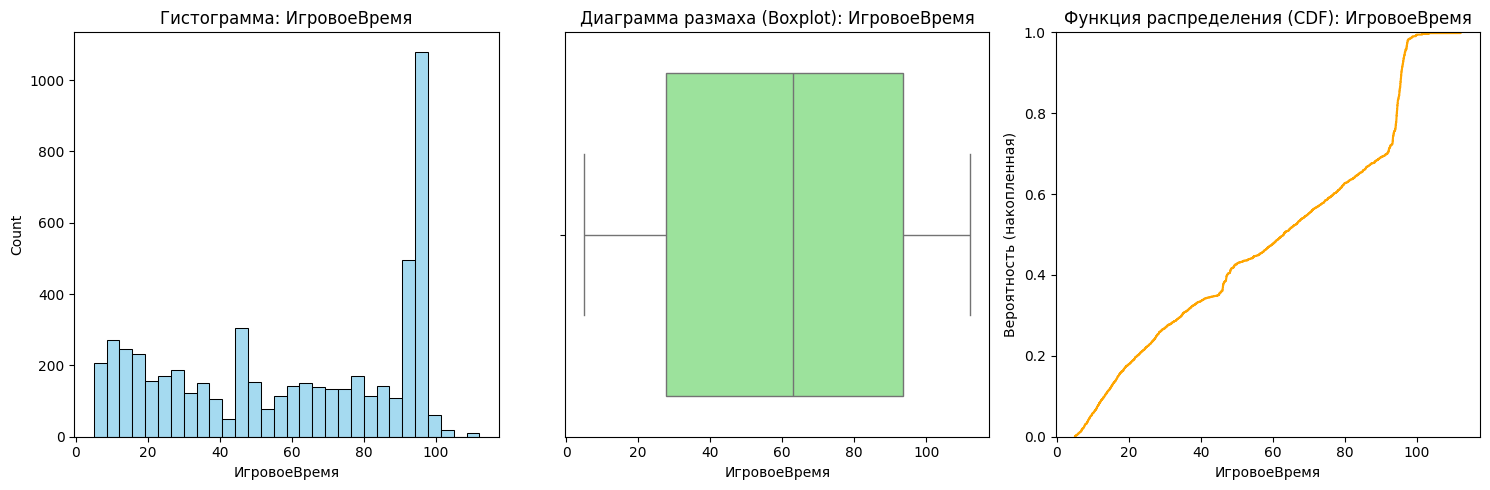

In [14]:
# Список выбранных столбцов
selected_columns = ['ИндексНаМатч_90', 'ИгровоеВремя']

# Гистограммы
for col in selected_columns:
    if col in pivot_df_2.columns:
        plt.figure(figsize=(15, 5))

        # Гистограмма
        plt.subplot(1, 3, 1)
        sns.histplot(pivot_df_2[col].dropna(), kde=False, bins=30, color='skyblue')
        plt.title(f'Гистограмма: {col}')
        plt.xlabel(col)

        # Диаграмма размаха (boxplot)
        plt.subplot(1, 3, 2)
        sns.boxplot(x=pivot_df_2[col], color='lightgreen')
        plt.title(f'Диаграмма размаха (Boxplot): {col}')

        # Функция распределения
        plt.subplot(1, 3, 3)
        try:
            sns.ecdfplot(pivot_df_2[col].dropna(), color='orange')
            plt.title(f'Функция распределения (CDF): {col}')
            plt.xlabel(col)
            plt.ylabel('Вероятность (накопленная)')
        except Exception as e:
            plt.text(0.5, 0.5, f'Ошибка: {e}', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Столбец '{col}' не найден в DataFrame")

In [15]:
# Считаем дисперсию до удаления
variance_index_2_before = pivot_df_2['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_2_before}")

threshold1 = -70
threshold = 190

data_delete_index_2 = pivot_df_2[pivot_df_2['ИндексНаМатч_90'] < threshold]
data_delete_index_2 = data_delete_index_2[data_delete_index_2['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_2_after = data_delete_index_2['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_2_after}")

Дисперсия до удаления: 2877.910516293379
Дисперсия после удаления: 2205.3634136291294


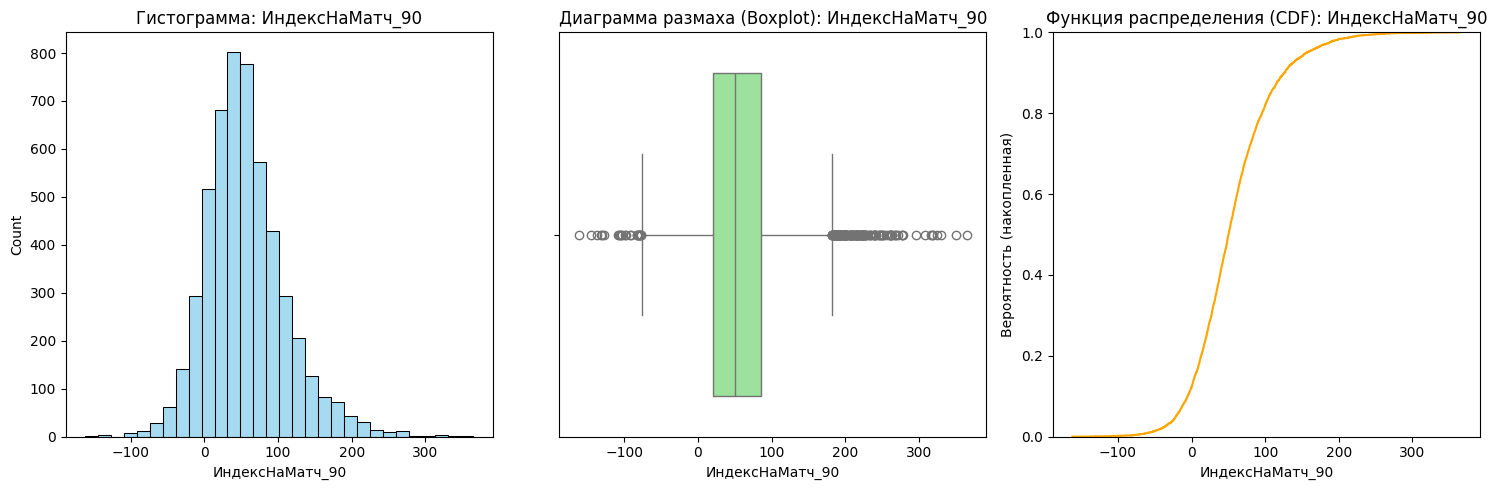

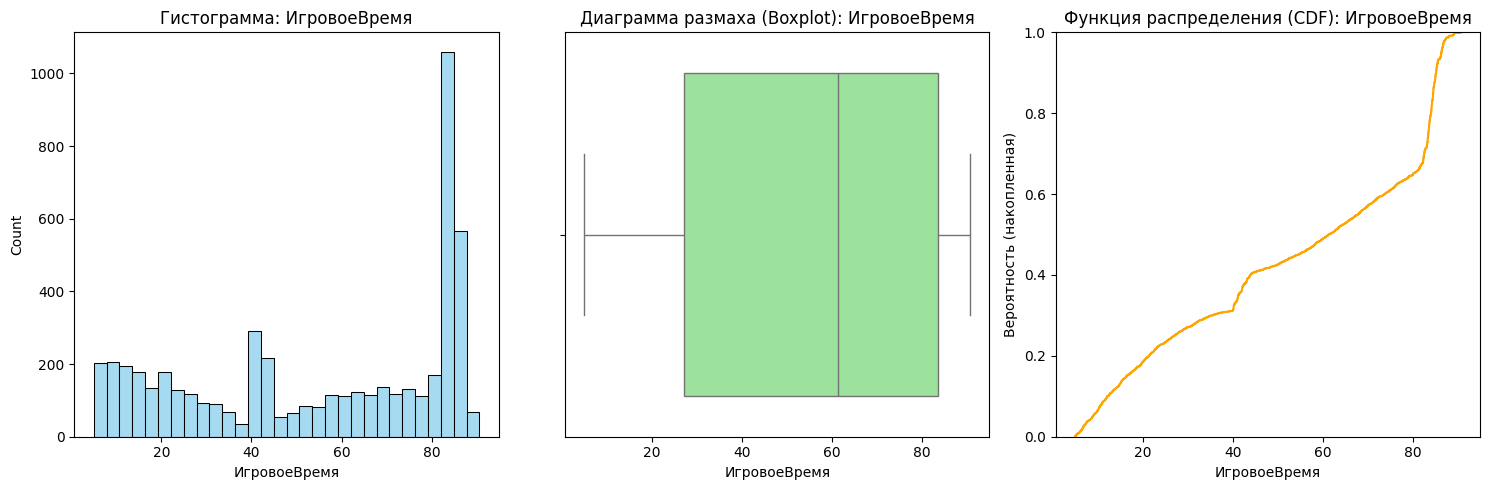

In [16]:
# Список выбранных столбцов
selected_columns = ['ИндексНаМатч_90', 'ИгровоеВремя']

# Гистограммы
for col in selected_columns:
    if col in pivot_df_3.columns:
        plt.figure(figsize=(15, 5))

        # Гистограмма
        plt.subplot(1, 3, 1)
        sns.histplot(pivot_df_3[col].dropna(), kde=False, bins=30, color='skyblue')
        plt.title(f'Гистограмма: {col}')
        plt.xlabel(col)

        # Диаграмма размаха (boxplot)
        plt.subplot(1, 3, 2)
        sns.boxplot(x=pivot_df_3[col], color='lightgreen')
        plt.title(f'Диаграмма размаха (Boxplot): {col}')

        # Функция распределения
        plt.subplot(1, 3, 3)
        try:
            sns.ecdfplot(pivot_df_3[col].dropna(), color='orange')
            plt.title(f'Функция распределения (CDF): {col}')
            plt.xlabel(col)
            plt.ylabel('Вероятность (накопленная)')
        except Exception as e:
            plt.text(0.5, 0.5, f'Ошибка: {e}', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Столбец '{col}' не найден в DataFrame")

In [17]:
# Считаем дисперсию до удаления
variance_index_3_before = pivot_df_3['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_3_before}")

threshold1 = -70
threshold = 190

data_delete_index_3 = pivot_df_3[pivot_df_3['ИндексНаМатч_90'] < threshold]
data_delete_index_3 = data_delete_index_3[data_delete_index_3['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_3_after = data_delete_index_3['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_3_after}")

Дисперсия до удаления: 3051.808064561194
Дисперсия после удаления: 2263.6589061009063


In [18]:
# Проверка текущих типов данных
print("Типы данных:")
print(data_delete_index_mp.dtypes)

Типы данных:
Данные
Турнир                                                         object
Игрок                                                          object
Амплуа                                                         object
Команда                                                        object
Матч                                                           object
                                                                ...  
Эффективность "+" Подбора мяча                                  int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга     int64
Эффективность "-" Обводки в зоне завершения                     int64
Эффективность "-" Подбора мяча                                  int64
Эффективность "-" Продвижения мяча вперед за счет дриблинга     int64
Length: 115, dtype: object


In [19]:
def convert_to_category(df, threshold):
    """
    Преобразование в категориальный тип
    """
    df_clean = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df[col])
            if unique_ratio < threshold: 
                df_clean[col] = df_clean[col].astype('category')
                print(f"{col} преобразована в category ({df[col].nunique()} уникальных значений)")

    return df_clean

df_mp = convert_to_category(data_delete_index_mp, threshold=0.1)
print(df_mp.dtypes)

Турнир преобразована в category (1 уникальных значений)
Игрок преобразована в category (509 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (162 уникальных значений)
Данные
Турнир                                                         category
Игрок                                                          category
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                

In [20]:
def convert_to_category(df, threshold):
    """
    Преобразование в категориальный тип
    """
    df_clean = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df[col])
            if unique_ratio < threshold:
                df_clean[col] = df_clean[col].astype('category')
                print(f"{col} преобразована в category ({df[col].nunique()} уникальных значений)")

    return df_clean

df1 = convert_to_category(data_delete_index_1, threshold=0.1)
print(df1.dtypes)

Турнир преобразована в category (1 уникальных значений)
Игрок преобразована в category (408 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (140 уникальных значений)
Данные
Турнир                                                         category
Игрок                                                          category
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                

In [21]:
def convert_to_category(df, threshold):
    """
    Преобразование в категориальный тип
    """
    df_clean = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df[col])
            if unique_ratio < threshold: 
                df_clean[col] = df_clean[col].astype('category')
                print(f"{col} преобразована в category ({df[col].nunique()} уникальных значений)")

    return df_clean

df2 = convert_to_category(data_delete_index_2, threshold=0.1)
print(df2.dtypes)

Турнир преобразована в category (1 уникальных значений)
Игрок преобразована в category (398 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (155 уникальных значений)
Данные
Турнир                                                         category
Игрок                                                          category
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                

In [22]:
def convert_to_category(df, threshold):
    """
    Преобразование в категориальный тип
    """
    df_clean = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df[col])
            if unique_ratio < threshold:
                df_clean[col] = df_clean[col].astype('category')
                print(f"{col} преобразована в category ({df[col].nunique()} уникальных значений)")

    return df_clean

df3 = convert_to_category(data_delete_index_3, threshold=0.1)
print(df3.dtypes)

Турнир преобразована в category (1 уникальных значений)
Игрок преобразована в category (404 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (156 уникальных значений)
Данные
Турнир                                                         category
Игрок                                                          category
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                

# Начнем делить наши датасеты на позиции и начнем обучение

In [23]:
# Способ 1: concat
combined_df = pd.concat([df1, df2, df3, df_mp], axis=0, ignore_index=True)

df_mp_w = combined_df[combined_df['Амплуа'] == 'W']

# Список нужных признаков
needed_columns = [
    'Турнир',
    'Игрок',
    'Амплуа',
    'Команда',
    'Матч',
    'ИндексНаМатч_90',
    'Блокировка навеса',
    'Блокировка передачи',
    'Блокировка удара',
    'Борьба за нейтральный мяч неудачная',
    'Борьба за нейтральный мяч удачная',
    'Голевой момент не реализовал',
    'Голевой момент реализовал',
    'Голевой момент создал',
    'Грубая голевая ошибка',
    'Грубая ошибка',
    'Единоборство вверху в атаке неудачное',
    'Единоборство вверху в атаке удачное',
    'Единоборство вверху в обороне неудачное',
    'Единоборство вверху в обороне удачное',
    'Навес заблокированный',
    'Навес неточный',
    'Навес точный',
    'Обводка в зоне завершения неудачная',
    'Обводка в зоне завершения удачная',
    'Обводка до зоны завершения неудачная',
    'Обводка до зоны завершения удачная',
    'Острая голевая передача',
    'Отбор при обводке соперника неудачный',
    'Отбор при обводке соперника удачный',
    'Отбор удачный',
    'Открывание',
    'Офсайд',
    'Передача в борьбу -',
    'Передача в борьбу +',
    'Передача голевая',
    'Передача ключевая неточная',
    'Передача ключевая точная',
    'Передача прогрессивная неточная',
    'Передача прогрессивная точная',
    'Передача прогрессивная точная доп',
    'Перехват передачи',
    'Подбор мяча',
    'Прием мяча неудачный',
    'Прием мяча удачный',
    'Продвижение мяча вперед за счет дриблинга',
    'Удар в створ',
    'Удар в штангу и перекладину',
    'Удар мимо',
    'Удар отбитый полевым игроком',
    'Удар перехваченный',
    'Участие в голевой атаке',
    'Фол',
    'Фол на игроке',
    'Эффективность "-" Обводки в зоне завершения',
    'Эффективность "-" Подбора мяча',
    'Эффективность "-" Продвижения мяча вперед за счет дриблинга',
    'Эффективность "+" Обводки в зоне завершения',
    'Эффективность "+" Подбора мяча',
    'Эффективность "+" Продвижения мяча вперед за счет дриблинга'
]

# Оставляем только нужные колонки в датафрейме
df_mp_w = df_mp_w[needed_columns]

df_mp_w


Данные,Турнир,Игрок,Амплуа,Команда,Матч,ИндексНаМатч_90,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга","Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга"
34,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Академия Коноплева U-18 0 : 0 Динамо Москва U-...,22.68414,0,0,0,4,...,0,0,1,0,0,0,0,1,1,2
35,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 0 : 2 СШОР Зенит U-18 (12.0...,57.41307,0,2,0,1,...,0,0,0,1,0,3,1,1,2,0
36,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 1 : 1 Академия Коноплева U-...,54.14139,1,1,0,2,...,0,0,0,0,0,1,1,0,3,0
37,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 1 : 2 Локомотив Москва U-18...,-0.06201,0,0,0,5,...,1,0,0,0,1,1,2,0,3,0
38,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 2 : 1 2008 г.р. (11.05.2025),39.26763,0,0,0,0,...,0,2,1,1,0,3,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20651,Молодежное первенство,Шопин Дмитрий (2007 Спартак Москва),W,Спартак Москва-М,Урал-М 0 : 4 Спартак Москва-М (18.04.2025),100.59255,0,1,0,1,...,0,0,2,3,1,0,1,1,0,1
20701,Молодежное первенство,Элезян Гарик (2007),W,"ФК ""Факел-М""","Ахмат-М 3 : 0 ФК ""Факел-М"" (18.07.2025)",38.99016,0,0,0,1,...,0,0,1,0,0,2,0,0,1,0
20702,Молодежное первенство,Элезян Гарик (2007),W,"ФК ""Факел-М""","ФК ""Факел-М"" 0 : 0 Рубин-М (29.08.2025)",26.95230,0,1,0,2,...,0,0,1,0,0,1,0,0,2,0
20703,Молодежное первенство,Элезян Гарик (2007),W,"ФК ""Факел-М""","ФК ""Факел-М"" 3 : 2 Ростов-М (11.07.2025)",2.97000,1,0,0,2,...,0,0,1,0,0,1,0,1,2,0


In [99]:
X = df_mp_w.drop(columns=['ИндексНаМатч_90', 'Матч', 'Турнир', 'Команда', 'Игрок','Амплуа'])
y = df_mp_w['ИндексНаМатч_90'].values


In [100]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Размеры данных:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


Размеры данных:
X_train: (2625, 54), y_train: (2625,)
X_test: (657, 54), y_test: (657,)


In [101]:
from lion_pytorch import Lion
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')

In [102]:
# Проверяем доступность GPU Apple Silicon (MPS)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: mps


In [118]:
class FootballNet(nn.Module):
    def __init__(self, input_size):
        super(FootballNet, self).__init__()
        self.network = nn.Sequential(
            # Первый слой с BatchNorm
            nn.Linear(input_size, 128),
            #nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3), #0.3
            
            # Второй слой
            nn.Linear(128, 64),
            #nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2), #0.2
            
            # Третий слой
            nn.Linear(64, 32),
            #nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.05), #0.05
            
            # Выходной слой
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)



In [119]:
# 3. Функция обучения
def train_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    """Обучение модели"""
    model.to(device)
    
    # Преобразуем данные в тензоры PyTorch - y_train и y_test уже numpy arrays
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).to(device).view(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.FloatTensor(y_test).to(device).view(-1, 1)
    
    # Функция потерь и оптимизатор
    criterion = nn.HuberLoss()  
    optimizer = Lion(model.parameters(), lr=0.001, weight_decay=1e-5)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses = []
    test_losses = []
    
    print("Начинаем обучение...")
    for epoch in range(epochs):
        model.train()
        
        # Мини-батчи
        for i in range(0, len(X_train_tensor), batch_size):
            batch_X = X_train_tensor[i:i+batch_size]
            batch_y = y_train_tensor[i:i+batch_size]
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        
        # Валидация
        model.eval()
        with torch.no_grad():
            train_outputs = model(X_train_tensor)
            train_loss = criterion(train_outputs, y_train_tensor)
            
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            
            scheduler.step(test_loss)
        
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
        
    # Предсказания на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_tensor).cpu().numpy()

    # Расчет метрик
    from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

    mae = mean_absolute_error(y_test, test_predictions)
    r2 = r2_score(y_test, test_predictions)
    mse = mean_squared_error(y_test, test_predictions)
    rmse = np.sqrt(mse)

    print(f"\n=== РЕЗУЛЬТАТЫ МОДЕЛИ ===")
    print(f"MAE (Средняя абсолютная ошибка): {mae:.4f}")
    print(f"R² Score (Коэффициент детерминации): {r2:.4f}")
    print(f"MSE (Средняя квадратичная ошибка): {mse:.4f}")
    print(f"RMSE (Средняя квадратичная ошибка): {rmse:.4f}")

    # Базовая метрика для сравнения
    mean_actual = y_test.mean()
    print(f"Среднее значение целевой переменной: {mean_actual:.4f}")
    print(f"MAE относительно среднего: {mae/mean_actual:.2%}")
    
    return train_losses, test_losses


In [120]:
# 4. Основная функция
def main():
    
    try:
        print(f"Размеры данных:")
        print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
        print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
        # Создание модели
        input_size = X_train.shape[1]
        model = FootballNet(input_size)
        print(f"Модель создана. Размер входа: {input_size}")
        print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")
        
        # Обучение
        train_losses, test_losses = train_model(
            model, X_train, y_train, X_test, y_test, 
            epochs=20, batch_size=64
        )
        
        # График обучения
        plt.figure(figsize=(10, 6))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(test_losses, label='Test Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Learning Curve')
        plt.legend()
        plt.show()
        
        # Сохранение модели
        torch.save(model.state_dict(), 'football_model.pth')
        print("Модель сохранена как 'football_model.pth'")
        
    except Exception as e:
        print(f"Ошибка: {e}")
        print("Проверьте путь к файлу и структуру данных")


Размеры данных:
X_train: (2625, 54), y_train: (2625,)
X_test: (657, 54), y_test: (657,)
Модель создана. Размер входа: 54
Количество параметров: 17,409
Начинаем обучение...
Epoch [10/20], Train Loss: 12.0561, Test Loss: 12.9018
Epoch [20/20], Train Loss: 9.5044, Test Loss: 10.8774

=== РЕЗУЛЬТАТЫ МОДЕЛИ ===
MAE (Средняя абсолютная ошибка): 11.3596
R² Score (Коэффициент детерминации): 0.8205
MSE (Средняя квадратичная ошибка): 315.4587
RMSE (Средняя квадратичная ошибка): 17.7612
Среднее значение целевой переменной: 45.5803
MAE относительно среднего: 24.92%


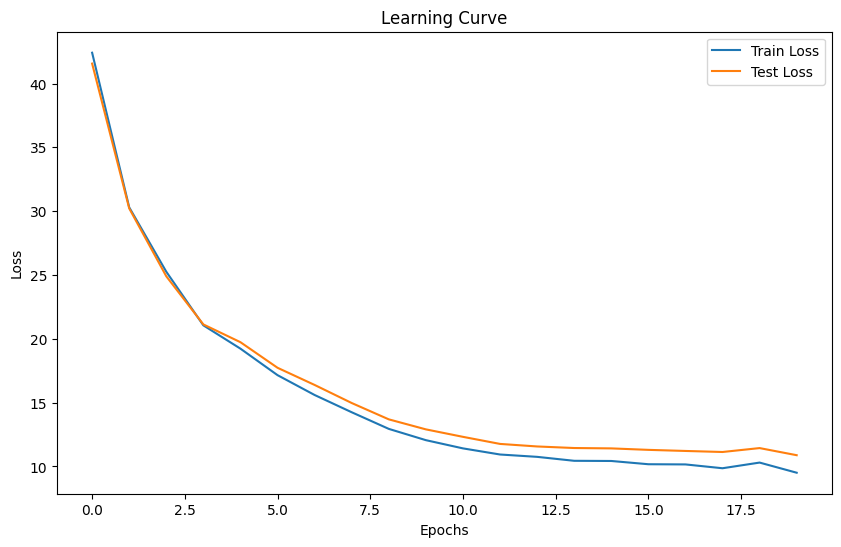

Модель сохранена как 'football_model.pth'


In [125]:
main()

In [126]:
from sklearn.metrics import r2_score

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = FootballNet(X_train.shape[1])
model.load_state_dict(torch.load('football_model.pth'))
model.to(device)
model.eval()

print("Модель загружена!")

feature_names = X.columns.tolist() 

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device).view(-1, 1)

# 6. Permutation Feature Importance
with torch.no_grad():
    baseline_predictions = model(X_test_tensor).cpu().numpy()
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline R²: {baseline_r2:.4f}")

feature_importance = {}
n_repeats = 5  # Количество повторений для усреднения

for i, feature_name in enumerate(feature_names):
    importances = []
    
    for repeat in range(n_repeats):
        X_test_perturbed = X_test.copy()
        np.random.seed(42 + repeat) 
        X_test_perturbed[:, i] = np.random.permutation(X_test_perturbed[:, i])
        
        X_test_perturbed_tensor = torch.FloatTensor(X_test_perturbed).to(device)
        with torch.no_grad():
            perturbed_predictions = model(X_test_perturbed_tensor).cpu().numpy()
        
        perturbed_r2 = r2_score(y_test, perturbed_predictions)
        importance = baseline_r2 - perturbed_r2
        importances.append(importance)
    
    # Усредняем результаты
    feature_importance[feature_name] = np.mean(importances)

sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("\n=== ТОП ВАЖНЕЙШИХ ПРИЗНАКОВ ===")
for i, (feature, importance) in enumerate(sorted_importance[:120]):
    print(f"{i+1}. {feature}: {importance:.6f}")

results_df = pd.DataFrame(sorted_importance, columns=['Признак', 'Важность'])

results_df.to_excel('feature_importance.xlsx', index=False)

print("Результаты сохранены в 'feature_importance.xlsx'")

Модель загружена!
Baseline R²: 0.8205

=== ТОП ВАЖНЕЙШИХ ПРИЗНАКОВ ===
1. Прием мяча удачный: 0.865897
2. Передача прогрессивная неточная: 0.329317
3. Передача прогрессивная точная: 0.269500
4. Борьба за нейтральный мяч неудачная: 0.235565
5. Эффективность "+" Продвижения мяча вперед за счет дриблинга: 0.227110
6. Отбор при обводке соперника неудачный: 0.117092
7. Эффективность "+" Подбора мяча: 0.096668
8. Продвижение мяча вперед за счет дриблинга: 0.085648
9. Прием мяча неудачный: 0.083341
10. Единоборство вверху в атаке неудачное: 0.072038
11. Обводка в зоне завершения удачная: 0.063716
12. Навес неточный: 0.054477
13. Перехват передачи: 0.049419
14. Эффективность "+" Обводки в зоне завершения: 0.045151
15. Борьба за нейтральный мяч удачная: 0.044244
16. Эффективность "-" Подбора мяча: 0.043793
17. Фол: 0.042746
18. Голевой момент создал: 0.039405
19. Обводка до зоны завершения неудачная: 0.037685
20. Передача в борьбу -: 0.037666
21. Обводка до зоны завершения удачная: 0.033794
22.

Теперь сделаем модель машинного обучения, которая будет решать задачу регресии и сравним эти две модели

In [62]:
df_mp_w

Данные,Турнир,Игрок,Амплуа,Команда,Матч,ИндексНаМатч_90,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга","Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга"
34,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Академия Коноплева U-18 0 : 0 Динамо Москва U-...,22.68414,0,0,0,4,...,0,0,1,0,0,0,0,1,1,2
35,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 0 : 2 СШОР Зенит U-18 (12.0...,57.41307,0,2,0,1,...,0,0,0,1,0,3,1,1,2,0
36,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 1 : 1 Академия Коноплева U-...,54.14139,1,1,0,2,...,0,0,0,0,0,1,1,0,3,0
37,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 1 : 2 Локомотив Москва U-18...,-0.06201,0,0,0,5,...,1,0,0,0,1,1,2,0,3,0
38,ЮФЛ-1,Босов Роман (2008 Динамо Москва),W,Динамо Москва U-18,Динамо Москва U-18 2 : 1 2008 г.р. (11.05.2025),39.26763,0,0,0,0,...,0,2,1,1,0,3,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20651,Молодежное первенство,Шопин Дмитрий (2007 Спартак Москва),W,Спартак Москва-М,Урал-М 0 : 4 Спартак Москва-М (18.04.2025),100.59255,0,1,0,1,...,0,0,2,3,1,0,1,1,0,1
20701,Молодежное первенство,Элезян Гарик (2007),W,"ФК ""Факел-М""","Ахмат-М 3 : 0 ФК ""Факел-М"" (18.07.2025)",38.99016,0,0,0,1,...,0,0,1,0,0,2,0,0,1,0
20702,Молодежное первенство,Элезян Гарик (2007),W,"ФК ""Факел-М""","ФК ""Факел-М"" 0 : 0 Рубин-М (29.08.2025)",26.95230,0,1,0,2,...,0,0,1,0,0,1,0,0,2,0
20703,Молодежное первенство,Элезян Гарик (2007),W,"ФК ""Факел-М""","ФК ""Факел-М"" 3 : 2 Ростов-М (11.07.2025)",2.97000,1,0,0,2,...,0,0,1,0,0,1,0,1,2,0


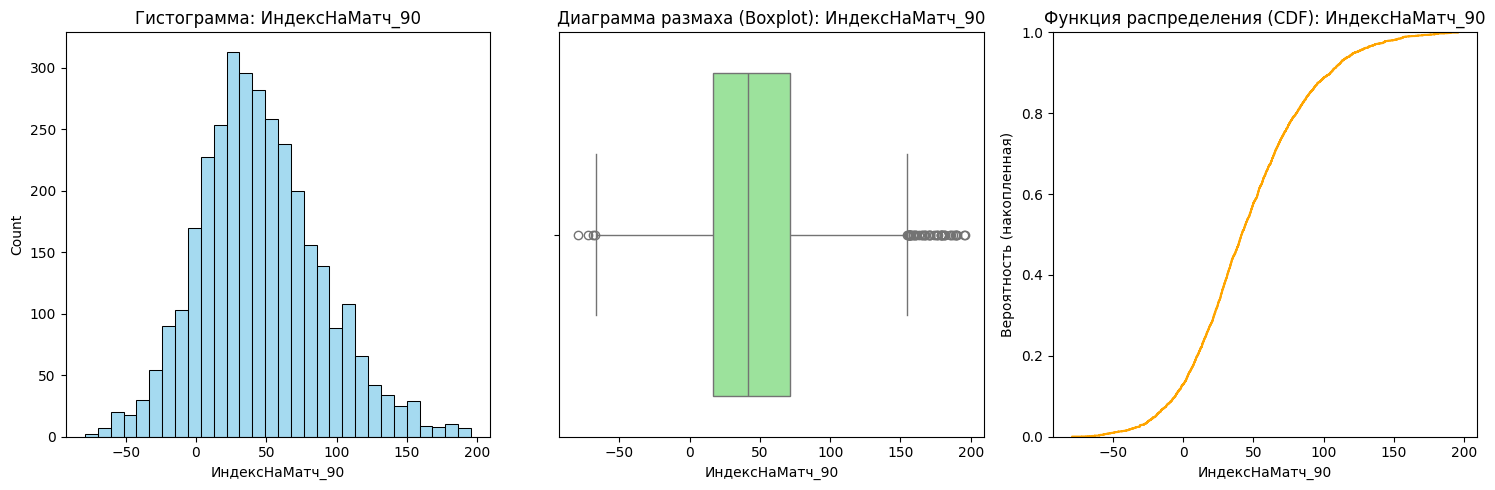

In [66]:
# Список выбранных столбцов
selected_columns = ['ИндексНаМатч_90']

# Гистограммы
for col in selected_columns:
    if col in df_mp_w.columns:
        plt.figure(figsize=(15, 5))

        # Гистограмма
        plt.subplot(1, 3, 1)
        sns.histplot(df_mp_w[col].dropna(), kde=False, bins=30, color='skyblue')
        plt.title(f'Гистограмма: {col}')
        plt.xlabel(col)

        # Диаграмма размаха (boxplot)
        plt.subplot(1, 3, 2)
        sns.boxplot(x=df_mp_w[col], color='lightgreen')
        plt.title(f'Диаграмма размаха (Boxplot): {col}')

        # Функция распределения
        plt.subplot(1, 3, 3)
        try:
            sns.ecdfplot(df_mp_w[col].dropna(), color='orange')
            plt.title(f'Функция распределения (CDF): {col}')
            plt.xlabel(col)
            plt.ylabel('Вероятность (накопленная)')
        except Exception as e:
            plt.text(0.5, 0.5, f'Ошибка: {e}', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Столбец '{col}' не найден в DataFrame")

In [67]:
# Считаем дисперсию до удаления
variance_index_before = df_mp_w['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_before}")

threshold1 = -50
threshold = 150

data_delete_index = df_mp_w[df_mp_w['ИндексНаМатч_90'] < threshold]
data_delete_index = data_delete_index[data_delete_index['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_after = data_delete_index['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_after}")

Дисперсия до удаления: 1881.9027488743245
Дисперсия после удаления: 1534.3299010944622


In [68]:
df_scaler = data_delete_index.drop(['Турнир', 'Игрок', 'Амплуа', 'Матч','Команда'], axis=1)

In [69]:
X = df_scaler.drop(['ИндексНаМатч_90'], axis=1)
y = df_scaler['ИндексНаМатч_90']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

In [71]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}
    print(f"{name}: MSE = {mse:.4f}, R2 = {r2:.4f}")

Linear Regression: MSE = 509.1629, R2 = 0.6600
Random Forest: MSE = 485.8205, R2 = 0.6756
Gradient Boosting: MSE = 401.1053, R2 = 0.7321
XGBoost: MSE = 393.3850, R2 = 0.7373
SVR: MSE = 670.3563, R2 = 0.5523


In [89]:
scoring = {
    'r2': 'r2',
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'mse': 'neg_mean_squared_error'
}

param_grid = {
    'n_estimators': [900, 1500],
    'max_depth': [2, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.4, 0.7, 0.9],
    'reg_lambda': [2, 3]
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
best_model = xgb.XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    best_model, 
    param_grid, 
    cv=5, 
    scoring=mae_scorer,
    refit='r2',
    return_train_score=True,
    n_jobs=1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

test_predictions = best_model.predict(X_test)

mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)

mean_actual = y_test.mean()
std_actual = y_test.std()
min_actual = y_test.min()
max_actual = y_test.max()

mae_relative = mae / mean_actual
rmse_relative = rmse / mean_actual

print("=" * 60)
print("ФИНАЛЬНЫЙ АНАЛИЗ МОДЕЛИ")
print("=" * 60)

print(f"\n📊 СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (рейтинг игрока):")
print(f"   Среднее значение: {mean_actual:.2f}")
print(f"   Стандартное отклонение: {std_actual:.2f}")
print(f"   Диапазон: [{min_actual:.2f}, {max_actual:.2f}]")

print(f"\n🎯 ЛУЧШИЕ ПАРАМЕТРЫ МОДЕЛИ:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📈 МЕТРИКИ КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"   R² (коэффициент детерминации): {r2:.4f}")
print(f"   MSE (средняя квадратичная ошибка): {mse:.4f}")
print(f"   RMSE (среднеквадратичная ошибка): {rmse:.4f}")
print(f"   MAE (средняя абсолютная ошибка): {mae:.4f}")

print(f"\n📊 ОТНОСИТЕЛЬНЫЕ ОШИБКИ:")
print(f"   MAE / Среднее значение: {mae_relative:.2%}")
print(f"   RMSE / Среднее значение: {rmse_relative:.2%}")
print(f"   MAE / Стандартное отклонение: {mae/std_actual:.2%}")

print(f"\n🔍 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
print(f"   • Модель объясняет {r2:.1%} дисперсии рейтингов игроков")
print(f"   • Средняя ошибка предсказания: {mae:.2f} пунктов рейтинга")
print(f"   • Ошибка составляет {mae_relative:.1%} от среднего рейтинга")

if mae_relative < 0.05:
    print(f"   ✅ ОТЛИЧНО: ошибка менее 5%")
elif mae_relative < 0.1:
    print(f"   👍 ХОРОШО: ошибка менее 10%")
elif mae_relative < 0.15:
    print(f"   ⚠️  УДОВЛЕТВОРИТЕЛЬНО: ошибка менее 15%")
else:
    print(f"   ❗ НУЖДАЕТСЯ В УЛУЧШЕНИИ: ошибка более 15%")

print(f"\n💡 РЕКОМЕНДАЦИИ:")
if r2 > 0.7:
    print("   • Модель имеет высокую предсказательную способность")
    print("   • Можно использовать для практических применений")
elif r2 > 0.5:
    print("   • Модель имеет среднюю предсказательную способность") 
    print("   • Рассмотрите добавление новых признаков")
else:
    print("   • Модель требует значительного улучшения")
    print("   • Проанализируйте важность признаков")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
ФИНАЛЬНЫЙ АНАЛИЗ МОДЕЛИ

📊 СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (рейтинг игрока):
   Среднее значение: 45.85
   Стандартное отклонение: 38.73
   Диапазон: [-43.35, 149.09]

🎯 ЛУЧШИЕ ПАРАМЕТРЫ МОДЕЛИ:
   learning_rate: 0.05
   max_depth: 2
   n_estimators: 1500
   reg_lambda: 3
   subsample: 0.4

📈 МЕТРИКИ КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ:
   R² (коэффициент детерминации): 0.8219
   MSE (средняя квадратичная ошибка): 266.6281
   RMSE (среднеквадратичная ошибка): 16.3288
   MAE (средняя абсолютная ошибка): 12.0283

📊 ОТНОСИТЕЛЬНЫЕ ОШИБКИ:
   MAE / Среднее значение: 26.23%
   RMSE / Среднее значение: 35.61%
   MAE / Стандартное отклонение: 31.06%

🔍 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
   • Модель объясняет 82.2% дисперсии рейтингов игроков
   • Средняя ошибка предсказания: 12.03 пунктов рейтинга
   • Ошибка составляет 26.2% от среднего рейтинга
   ❗ НУЖДАЕТСЯ В УЛУЧШЕНИИ: ошибка более 15%

💡 РЕКОМЕНДАЦИИ:
   • Модель имеет высокую предсказательную

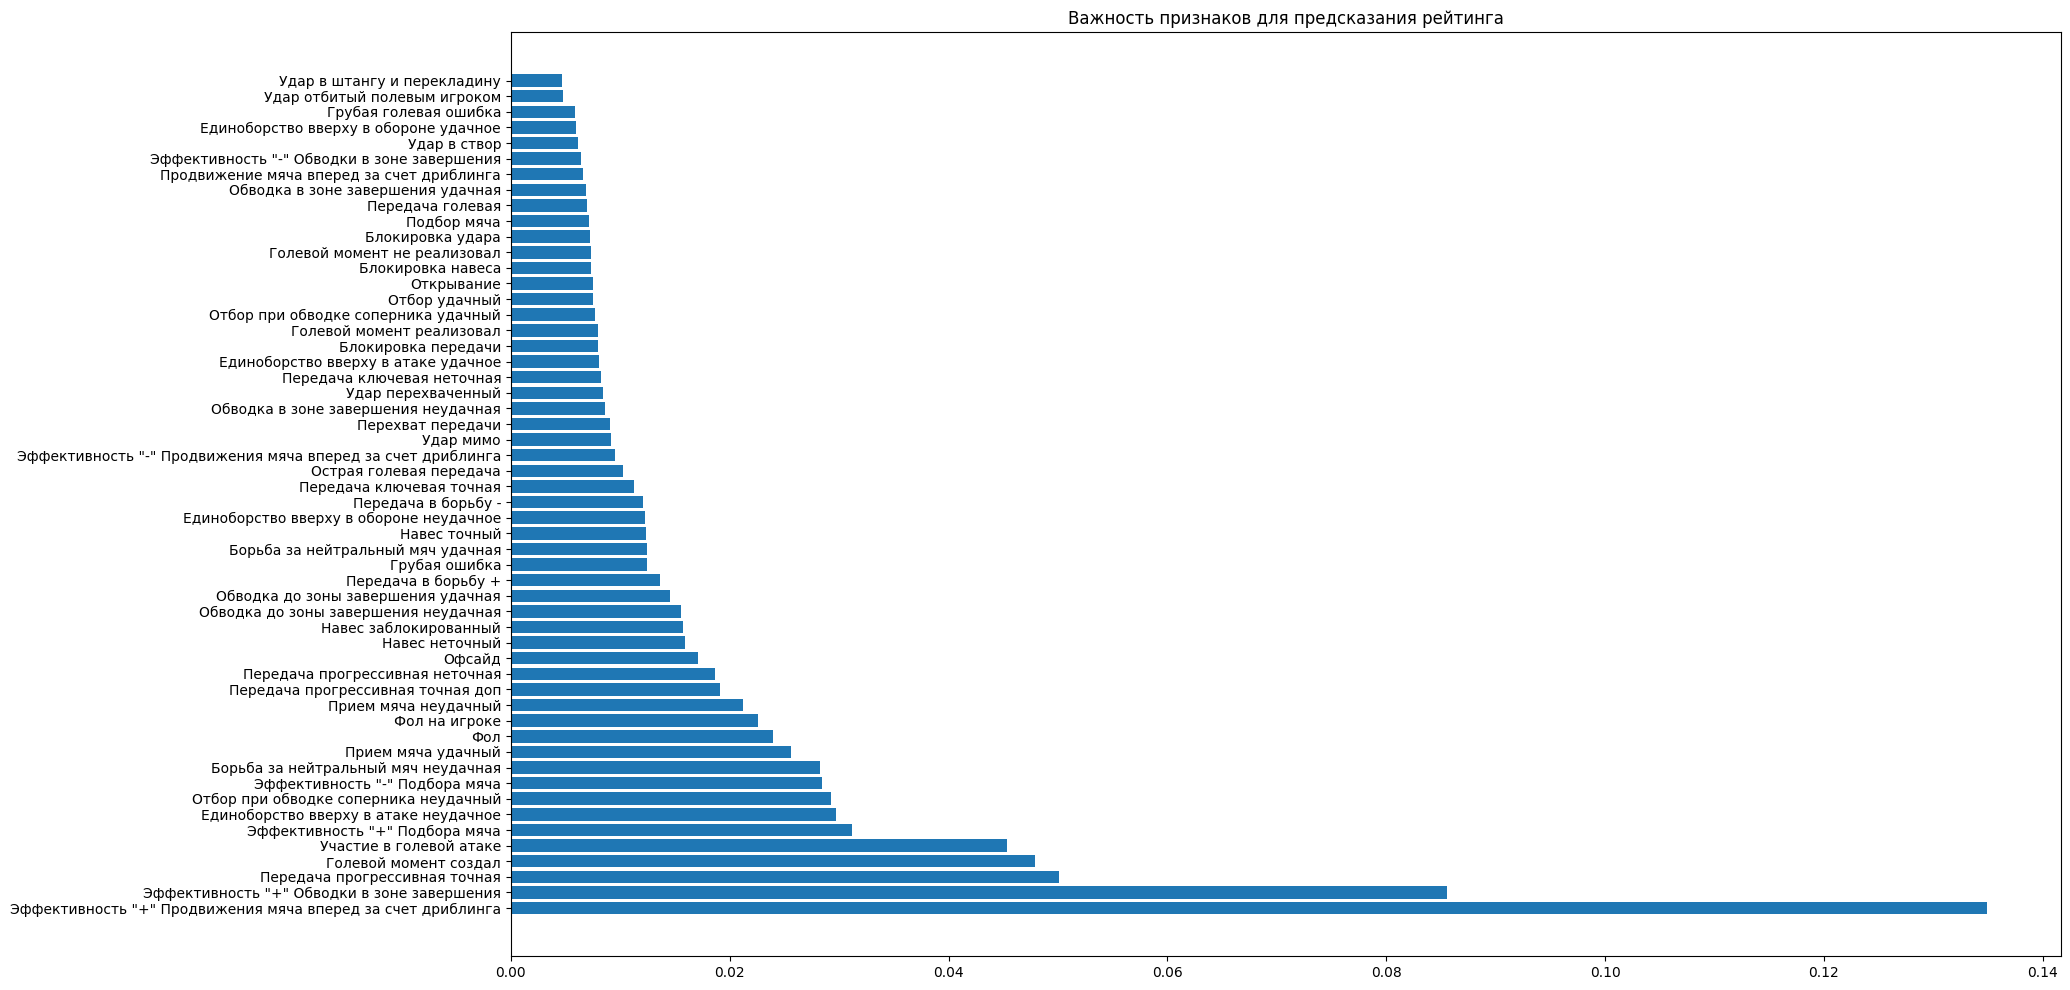

In [90]:
# Обучение финальной модели
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(20, 12))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Важность признаков для предсказания рейтинга')
plt.show()

Финальные метрики:
MSE: 266.6281
R2: 0.8219


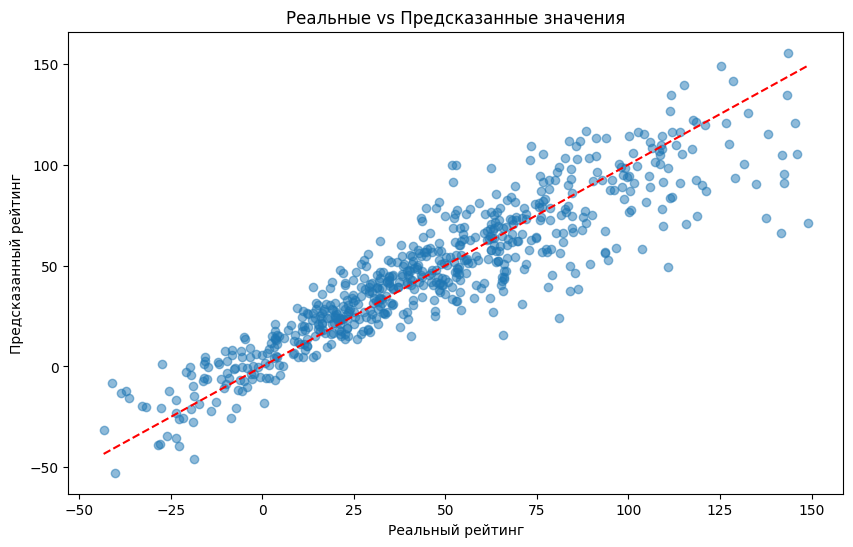

In [91]:
# Предсказания на тестовой выборке
y_pred_final = final_model.predict(X_test)

# Метрики качества
final_mse = mean_squared_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

print(f"Финальные метрики:")
print(f"MSE: {final_mse:.4f}")
print(f"R2: {final_r2:.4f}")

# Визуализация предсказаний
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальный рейтинг')
plt.ylabel('Предсказанный рейтинг')
plt.title('Реальные vs Предсказанные значения')
plt.show()


In [92]:
import joblib
import datetime

# Сохраняем модель
model_filename = f"football_rating_model_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}.pkl"
joblib.dump(final_model, model_filename)
print(f"✅ Модель сохранена как: {model_filename}")

# Сохраняем также preprocessing objects если нужно
preprocessing_objects = {
    'model': final_model,
    'feature_names': X_train.columns.tolist(),
    'training_date': datetime.datetime.now(),
    'model_metrics': {
        'r2': r2,
        'mae': mae,
        'mse': mse
    }
}

joblib.dump(preprocessing_objects, f"full_pipeline_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}.pkl")

✅ Модель сохранена как: football_rating_model_20251014_2054.pkl


['full_pipeline_20251014_2054.pkl']